In [21]:
# CELL 1 — IMPORTS & CONFIG
!pip install -q dandi remfile pynwb h5py scikit-learn caveclient pandas matplotlib
import os, re, glob
import numpy as np
import pandas as pd
import warnings
import h5py, remfile
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

METADATA_PATH    = '/content/drive/MyDrive/microns activity data/metadata.pkl'
RESULTS_DIR      = '/content/drive/MyDrive/microns activity data/decoding_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

N_BOOTSTRAPS     = 5
MIN_NEURON_FLOOR = 20
CLASSES          = ['Cinematic', 'Rendered', 'sports1m']
AREA_ORDER       = ['V1', 'LM', 'AL', 'RL']

ALL_SESSIONS_META = [
    (4, 7), (5, 6), (5, 7), (6, 2), (6, 4),
    (6, 6), (6, 7), (7, 3), (7, 4), (7, 5),
    (8, 5), (9, 3), (9, 4), (9, 6),
]

# ── CHANGE EACH RUN ───────────────────────────────────────────
SESSION  = 6
SCAN     = 4
NWB_PATH = 'sub-17797/sub-17797_ses-6-scan-4_behavior+image+ophys.nwb'
# ─────────────────────────────────────────────────────────────

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# CELL 2 — FUNCTIONS

def load_and_align_data(nwb_path, metadata_path, session, scan):
    client      = DandiAPIClient()
    dandiset    = client.get_dandiset("000402", "draft")
    asset       = next(a for a in dandiset.get_assets() if a.path == nwb_path)
    s3_url      = asset.get_content_url(follow_redirects=1, strip_query=True)
    remote_file = remfile.File(s3_url)
    h5_file     = h5py.File(remote_file, "r")
    io          = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwb         = io.read()

    meta   = pd.read_pickle(metadata_path)
    merged = meta[(meta['session'] == session) & (meta['scan_idx'] == scan)].copy()
    merged = merged.drop_duplicates(subset='unit_id').reset_index(drop=True)
    merged['depth_bin'] = merged['um_z'].astype(float).fillna(0).astype(int)
    unit_ids = merged['unit_id'].values

    fc          = nwb.processing['ophys'].data_interfaces['Fluorescence'].roi_response_series
    combined    = np.concatenate([fc[f'RoiResponseSeries{i}'].data[:] for i in range(1, 9)], axis=1)
    frame_times = fc['RoiResponseSeries1'].timestamps[:]
    aligned     = combined[:, unit_ids - 1].T
    del combined

    trials = nwb.intervals['Clip'].to_dataframe()
    trials = trials[trials['short_movie_name'].isin(CLASSES)]

    io.close(); h5_file.close(); remote_file.close()
    print(f"  Aligned: {aligned.shape} | Trials: {len(trials)}")
    return aligned, frame_times, trials, merged


def extract_features(activity, frame_times, trials):
    X, y = [], []
    for _, trial in trials.iterrows():
        mask = (frame_times >= trial.start_time) & (frame_times < trial.stop_time)
        X.append(activity[:, mask].mean(axis=1))
        y.append(trial.short_movie_name)
    return np.array(X), np.array(y)


def compute_global_floors(metadata_path, all_sessions_meta, min_floor):
    meta = pd.read_pickle(metadata_path)
    area_mins, depth_mins = [], []
    for session, scan in all_sessions_meta:
        sub = meta[(meta['session'] == session) & (meta['scan_idx'] == scan)].copy()
        sub = sub.drop_duplicates(subset='unit_id')
        sub['depth_bin'] = sub['um_z'].astype(float).fillna(0).astype(int)
        area_mins.append(sub['brain_area'].value_counts().min())
        depth_mins.append(sub['depth_bin'].value_counts().min())
    floor_area  = max(int(np.percentile(area_mins,  25)), min_floor)
    floor_depth = max(int(np.percentile(depth_mins, 25)), min_floor)
    print(f"Global floors — Area: {floor_area} | Depth: {floor_depth} | Area×Depth: {min_floor} (skip if too low)")
    return floor_area, floor_depth, min_floor


def run_decoder(X_sub, y, n_neurons, n_bootstraps):
    classes = np.unique(y)
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, shuf_accs, cms = [], [], []
    for b in range(n_bootstraps):
        rng    = np.random.RandomState(b)
        idx    = rng.choice(X_sub.shape[1], min(n_neurons, X_sub.shape[1]), replace=False)
        X_boot = StandardScaler().fit_transform(X_sub[:, idx])
        clf    = VotingClassifier(estimators=[
            ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)),
            ('svm', SVC(kernel='linear', class_weight='balanced', probability=True, C=1.0)),
        ], voting='soft')
        accs.append(np.mean(cross_val_score(clf, X_boot, y, cv=cv, scoring='accuracy')))
        cms.append(confusion_matrix(y, cross_val_predict(clf, X_boot, y, cv=cv),
                                    labels=classes, normalize='true'))
        shuf_accs.append(np.mean(cross_val_score(clf, X_boot, rng.permutation(y),
                                                  cv=cv, scoring='accuracy')))
    mean_cm = np.mean(cms, axis=0)
    per_class_recall = dict(zip(classes, np.diag(mean_cm)))
    return np.mean(accs), np.std(accs), np.mean(shuf_accs), mean_cm, classes, per_class_recall


def decode_session(X, y, merged, session, scan, floors, n_bootstraps, results_dir):
    label = f"s{session}_scan{scan}"
    floor_area, floor_depth, floor_both = floors
    rows, cm_store = [], {}

    def _run(mask, gtype, gname, n_sub, area=None, depth=None):
        if mask.sum() < n_sub:
            print(f"    SKIP {gname} (N={mask.sum()})"); return
        acc, std, chance, cm, classes, per_class = run_decoder(X[:, mask], y, n_sub, n_bootstraps)
        print(f"    {gname:<30} N={mask.sum():<5} Acc={acc:.3f}±{std:.3f} Chance={chance:.3f}")
        rows.append({
            'session': session, 'scan': scan,
            'Type': gtype, 'Group': gname,
            'Acc': acc, 'Std': std, 'Chance': chance,
            'N_neurons': mask.sum(), 'N_sub': n_sub,
            'brain_area': area, 'depth_bin': depth,
            'recall_Cinematic': per_class.get('Cinematic', np.nan),
            'recall_Rendered':  per_class.get('Rendered',  np.nan),
            'recall_sports1m':  per_class.get('sports1m',  np.nan),
        })
        cm_store[f"{gtype}|{gname}"] = {'cm': cm, 'classes': classes, 'acc': acc, 'chance': chance}

    print("  [Area]")
    for area in sorted(merged['brain_area'].dropna().unique()):
        mask = merged['brain_area'].values == area
        _run(mask, 'Area', area, floor_area, area=area)

    print("  [Depth]")
    for depth in sorted(merged['depth_bin'].dropna().unique()):
        mask = merged['depth_bin'].values == depth
        _run(mask, 'Depth', f"{depth}um", floor_depth, depth=depth)

    print("  [Area x Depth]")
    for area in sorted(merged['brain_area'].dropna().unique()):
        for depth in sorted(merged['depth_bin'].dropna().unique()):
            mask = (merged['brain_area'].values == area) & (merged['depth_bin'].values == depth)
            _run(mask, 'Area x Depth', f"{area}_{depth}um", floor_both, area=area, depth=depth)

    pd.DataFrame(rows).to_csv(f"{results_dir}/results_{label}.csv", index=False)

    # Save CM figure
    n_cms  = len(cm_store)
    n_cols = min(4, n_cms)
    n_rows = int(np.ceil(n_cms / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3.8), constrained_layout=True)
    axes = np.array(axes).flatten()
    for i, (key, val) in enumerate(cm_store.items()):
        sns.heatmap(val['cm'], annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                    xticklabels=val['classes'], yticklabels=val['classes'], vmin=0, vmax=1)
        axes[i].set_title(f"{key.split('|')[1]}\nAcc={val['acc']:.3f} Chance={val['chance']:.3f}", fontsize=8)
        axes[i].set_xlabel('Predicted', fontsize=7); axes[i].set_ylabel('True', fontsize=7)
    for i in range(n_cms, len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(f'CMs — {label}', fontsize=11, fontweight='bold')
    plt.savefig(f"{results_dir}/cm_{label}.png", dpi=130, bbox_inches='tight')
    plt.close()
    print(f"  Saved → {label}")

print("Functions loaded.")

Functions loaded.


In [10]:
# CELL 3 — GLOBAL FLOORS (run once)
floors = compute_global_floors(METADATA_PATH, ALL_SESSIONS_META, MIN_NEURON_FLOOR)

Global floors — Area: 291 | Depth: 1248 | Area×Depth: 20 (skip if too low)


In [22]:
# CELL 4 — RUN ONE SESSION
print(f"\n{'='*55}\ns{SESSION}_scan{SCAN}\n{'='*55}")
activity, frame_times, trials, merged = load_and_align_data(NWB_PATH, METADATA_PATH, SESSION, SCAN)
X, y = extract_features(activity, frame_times, trials)
del activity
decode_session(X, y, merged, SESSION, SCAN, floors, N_BOOTSTRAPS, RESULTS_DIR)
del X


s6_scan4
  Aligned: (8221, 40000) | Trials: 384
  [Area]
    AL                             N=317   Acc=0.620±0.006 Chance=0.334
    LM                             N=1027  Acc=0.649±0.033 Chance=0.330
    RL                             N=878   Acc=0.613±0.032 Chance=0.327
    V1                             N=5999  Acc=0.616±0.038 Chance=0.331
  [Depth]
    115um                          N=2118  Acc=0.693±0.011 Chance=0.364
    255um                          N=2679  Acc=0.707±0.011 Chance=0.364
    395um                          N=2182  Acc=0.767±0.011 Chance=0.328
    SKIP 535um (N=1242)
  [Area x Depth]
    AL_115um                       N=46    Acc=0.496±0.022 Chance=0.330
    AL_255um                       N=119   Acc=0.476±0.017 Chance=0.336
    AL_395um                       N=112   Acc=0.493±0.032 Chance=0.318
    AL_535um                       N=40    Acc=0.430±0.022 Chance=0.327
    LM_115um                       N=156   Acc=0.446±0.016 Chance=0.343
    LM_255um               

Loaded 5 session-scans | 116 rows


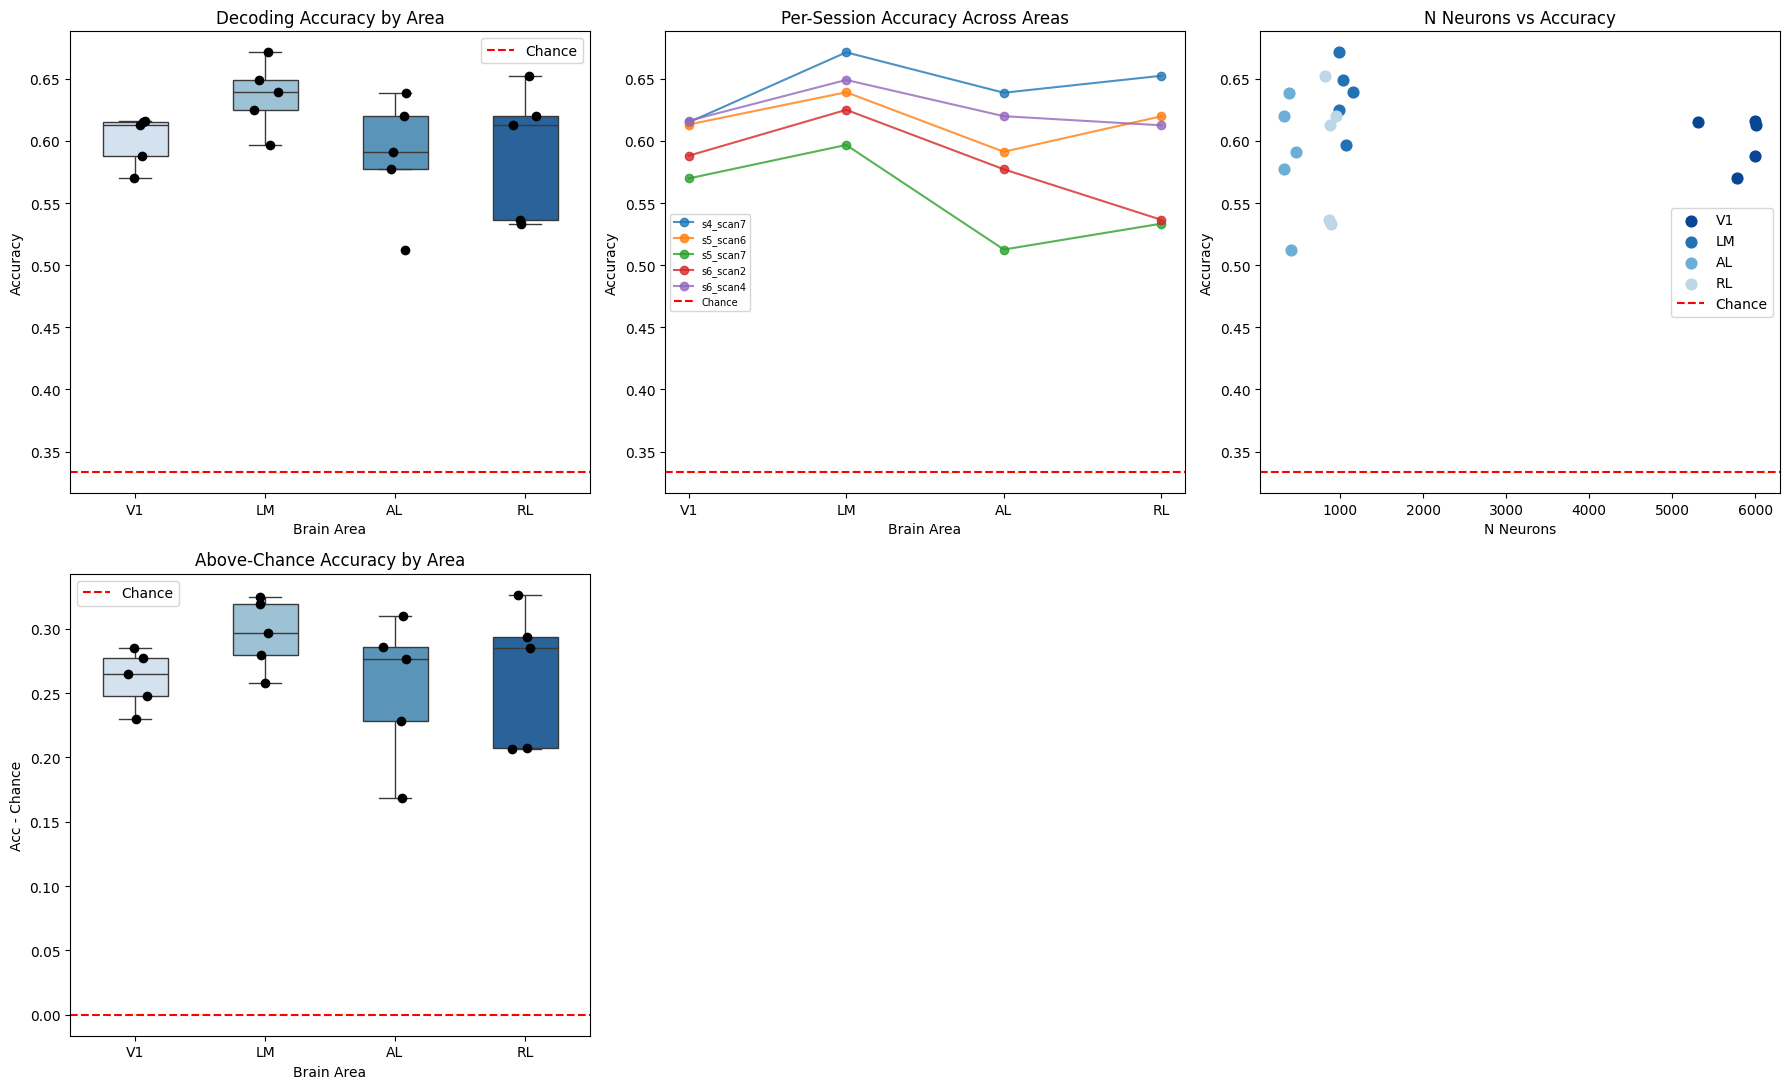

In [44]:
# CELL 5 — UPDATED ANALYSIS
df = pd.concat([pd.read_csv(f) for f in glob.glob(f"{RESULTS_DIR}/results_s*.csv")], ignore_index=True)
df['session_label'] = 's' + df['session'].astype(str) + '_scan' + df['scan'].astype(str)
df['AboveChance'] = df['Acc'] - df['Chance']
print(f"Loaded {df.groupby(['session','scan']).ngroups} session-scans | {len(df)} rows")

AREA_ORDER = ['V1', 'LM', 'AL', 'RL']
CLASSES    = ['Cinematic', 'Rendered Movie', 'sports1m']
area_df    = df[df['Type'] == 'Area'].copy()
area_df['brain_area'] = pd.Categorical(area_df['brain_area'], categories=AREA_ORDER, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Plot 1: Boxplot + strip (raw accuracy) ────────────────────
ax = axes[0,0]
sns.boxplot(data=area_df, x='brain_area', y='Acc', order=AREA_ORDER,
            palette='Blues', ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=area_df, x='brain_area', y='Acc', order=AREA_ORDER,
              color='black', size=7, jitter=True, ax=ax, zorder=5)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('Decoding Accuracy by Area'); ax.set_xlabel('Brain Area'); ax.set_ylabel('Accuracy')
ax.legend()

# ── Plot 2: Per-session lines across areas ────────────────────
ax = axes[0,1]
for sess in area_df['session_label'].unique():
    sub = area_df[area_df['session_label'] == sess].sort_values('brain_area')
    ax.plot(sub['brain_area'].astype(str), sub['Acc'], marker='o', label=sess, alpha=0.8)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('Per-Session Accuracy Across Areas')
ax.set_xlabel('Brain Area'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=7)

# ── Plot 3: N_neurons vs Acc scatter ─────────────────────────
ax = axes[0,2]
colors = {'V1':'#084594','LM':'#2171b5','AL':'#6baed6','RL':'#bdd7e7'}
for area in AREA_ORDER:
    sub = area_df[area_df['brain_area']==area]
    ax.scatter(sub['N_neurons'], sub['Acc'], label=area,
               color=colors[area], s=60, zorder=5)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('N Neurons vs Accuracy'); ax.set_xlabel('N Neurons'); ax.set_ylabel('Accuracy')
ax.legend()

# ── Plot 4: Above-chance by area (boxplot + strip) ────────────
ax = axes[1,0]
sns.boxplot(data=area_df, x='brain_area', y='AboveChance', order=AREA_ORDER,
            palette='Blues', ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=area_df, x='brain_area', y='AboveChance', order=AREA_ORDER,
              color='black', size=7, jitter=True, ax=ax, zorder=5)
ax.axhline(0, color='red', linestyle='--', label='Chance')
ax.set_title('Above-Chance Accuracy by Area')
ax.set_xlabel('Brain Area'); ax.set_ylabel('Acc - Chance')
ax.legend()

# hide unused
axes[1,2].set_visible(False)
axes[1,1].set_visible(False)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/analysis_plots.png", dpi=150, bbox_inches='tight')
plt.show()